In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Set working directory (adjust path as needed)
import os
PROJECT_DIR = '/content/drive/MyDrive/drugresponse'

# Check if directory exists
if os.path.exists(PROJECT_DIR):
    os.chdir(PROJECT_DIR)
    print(f"✓ Working directory: {os.getcwd()}")
else:
    print(f"⚠ Directory not found: {PROJECT_DIR}")
    print("Please upload your project to Google Drive first!")

✓ Working directory: /content/drive/MyDrive/drugresponse


In [3]:
# Install required packages
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric
!pip install -q rdkit
!pip install -q transformers
!pip install -q scikit-learn
!pip install -q seaborn matplotlib

print("✓ Packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 66.9 MB/s eta 0:00:00
✓ Packages installed


## 1. Setup and Load Data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, rankdata
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Paths
DATA_DIR = Path('./data/processed')
RESULTS_DIR = Path('./results')

print("✓ Setup complete")

✓ Setup complete


In [5]:
# Load dataset and splits
df = pd.read_parquet(DATA_DIR / 'merged.parquet')
train_idx = np.load(DATA_DIR / 'splits_drug/train_idx.npy')
val_idx = np.load(DATA_DIR / 'splits_drug/val_idx.npy')
test_idx = np.load(DATA_DIR / 'splits_drug/test_idx.npy')

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

y_train = df_train['ln_ic50'].values
y_val = df_val['ln_ic50'].values
y_test = df_test['ln_ic50'].values

print(f"Train: {len(df_train):,} samples")
print(f"Val:   {len(df_val):,} samples")
print(f"Test:  {len(df_test):,} samples")

Train: 395,596 samples
Val:   54,216 samples
Test:  112,977 samples


## 2. Load Model Predictions

In [6]:
# Dictionary to store predictions
predictions = {}

# Helper function to load predictions
def load_predictions(model_name, result_dir, use_npy=True):
    """Load test predictions from saved files"""
    try:
        # Always try to load test_preds.npy first
        path = RESULTS_DIR / result_dir / 'test_preds.npy'
        print(f"  Checking: {path}")
        print(f"  Exists: {path.exists()}")
        if path.exists():
            return np.load(path)
        # Fallback: regenerate from model if needed
        return None
    except Exception as e:
        print(f"⚠ Could not load {model_name}: {e}")
        return None

# Load available model predictions
models_to_load = [
    ('MLP Baseline', 'mlp_baseline_with_splits', True),
    ('MLP + ChemBERTa', 'mlp_chemberta', True),
    ('MLP + ChemBERTa (Tuned)', 'mlp_chemberta_tuned', False),
    ('ChemBERTa Finetuned', 'chemberta_finetune', False),
    ('GNN Baseline', 'gnn_baseline', False),
    ('GNN Tuned', 'gnn_tuned', False),
]

for model_name, result_dir, use_npy in models_to_load:
    preds = load_predictions(model_name, result_dir, use_npy)
    if preds is not None:
        predictions[model_name] = preds
        print(f"✓ Loaded {model_name}: {len(preds)} predictions")
    else:
        print(f"✗ {model_name} not available")

print(f"\nTotal models available: {len(predictions)}")

  Checking: results/mlp_baseline_with_splits/test_preds.npy
  Exists: True
✓ Loaded MLP Baseline: 112977 predictions
  Checking: results/mlp_chemberta/test_preds.npy
  Exists: True
✓ Loaded MLP + ChemBERTa: 112977 predictions
  Checking: results/mlp_chemberta_tuned/test_preds.npy
  Exists: False
✗ MLP + ChemBERTa (Tuned) not available
  Checking: results/chemberta_finetune/test_preds.npy
  Exists: False
✗ ChemBERTa Finetuned not available
  Checking: results/gnn_baseline/test_preds.npy
  Exists: False
✗ GNN Baseline not available
  Checking: results/gnn_tuned/test_preds.npy
  Exists: False
✗ GNN Tuned not available

Total models available: 2


## 3. Generate Missing Predictions

For models without saved test predictions, generate them from trained models.

In [7]:
import torch
import sys
sys.path.append('./src')
from models.mlp import MLP
from models.gnn import GINEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [15]:
# Prepare test features
chemberta_feats = np.load(DATA_DIR / 'chemberta_drug_feats.npz')

# Expression features (PCA components already in merged.parquet)
pc_cols = [col for col in df_test.columns if col.startswith('PC')]
X_expr_test = df_test[pc_cols].values

# Tissue encoding
tissue_encoder = {t: i for i, t in enumerate(df['tissue'].unique())}
X_tissue_test = np.array([tissue_encoder[t] for t in df_test['tissue']])

# Drug features
drug_ids_test = df_test['drug_id'].values
drug_id_to_idx = {int(did): i for i, did in enumerate(chemberta_feats['drug_id'])}
drug_indices = [drug_id_to_idx[int(did)] for did in drug_ids_test]
X_drug_test = chemberta_feats['feats'][drug_indices]

# Convert to tensors
X_expr_tensor = torch.FloatTensor(X_expr_test).to(device)
X_tissue_tensor = torch.LongTensor(X_tissue_test).to(device)
X_drug_tensor = torch.FloatTensor(X_drug_test).to(device)

print(f"✓ Test features prepared")
print(f"  Expression: {X_expr_test.shape}")
print(f"  Tissue: {X_tissue_test.shape}")
print(f"  Drug: {X_drug_test.shape}")

✓ Test features prepared
  Expression: (112977, 512)
  Tissue: (112977,)
  Drug: (112977, 768)


In [22]:
# Generate MLP + ChemBERTa (Tuned) predictions if missing
if 'MLP + ChemBERTa (Tuned)' not in predictions:
    try:
        model_path = RESULTS_DIR / 'mlp_chemberta_tuned/mlp_chemberta_best.pt'
        if model_path.exists():
            # Load checkpoint (may have nested structure)
            checkpoint = torch.load(model_path, map_location=device)

            # Extract state_dict and config if nested
            if 'state_dict' in checkpoint:
                state_dict = checkpoint['state_dict']
                best_params = checkpoint.get('best_params', {})
                hidden = best_params.get('hidden', None)
                dropout = best_params.get('dropout', 0.3)
            else:
                state_dict = checkpoint
                hidden = None
                dropout = 0.3

            # If hidden not in config, infer from state_dict shapes
            if hidden is None:
                hidden = []
                i = 0
                # Collect all hidden layer sizes (skip last which is output layer)
                while f'net.{i}.weight' in state_dict:
                    layer_out_dim = state_dict[f'net.{i}.weight'].shape[0]
                    hidden.append(layer_out_dim)
                    i += 3  # Skip weight, relu, dropout

                # Remove last element (it's the output layer with size 1)
                if hidden and hidden[-1] == 1:
                    hidden = hidden[:-1]

            # Get input dim from first layer
            in_dim = state_dict['net.0.weight'].shape[1]

            # Check if feature dimensions match
            expr_drug_dim = X_expr_test.shape[1] + X_drug_test.shape[1]
            if expr_drug_dim != in_dim:
                print(f"⚠ Feature dimension mismatch for MLP + ChemBERTa (Tuned):")
                print(f"  Model expects: {in_dim} features")
                print(f"  Available: {expr_drug_dim} features (expr: {X_expr_test.shape[1]}, drug: {X_drug_test.shape[1]})")
                print(f"  Missing: {in_dim - expr_drug_dim} features")
                print(f"  → Skipping generation (model trained with different feature set)")
            else:
                model = MLP(
                    in_dim=in_dim,
                    hidden=hidden,
                    dropout=dropout
                ).to(device)

                model.load_state_dict(state_dict)
                model.eval()

                # Concatenate expression and drug features
                X_combined = torch.cat([X_expr_tensor, X_drug_tensor], dim=1)

                with torch.no_grad():
                    preds = model(X_combined).cpu().numpy().flatten()

                predictions['MLP + ChemBERTa (Tuned)'] = preds
                print(f"✓ Generated MLP + ChemBERTa (Tuned) predictions (hidden={hidden})")
    except Exception as e:
        print(f"⚠ Could not generate MLP + ChemBERTa (Tuned): {e}")

# Generate ChemBERTa Finetuned predictions if missing
if 'ChemBERTa Finetuned' not in predictions:
    try:
        model_path = RESULTS_DIR / 'chemberta_finetune/chemberta_finetuned.pt'
        if model_path.exists():
            from transformers import AutoModel
            print("⚠ ChemBERTa Finetuned requires actual transformer model - skipping generation")
            print("  If you have the .npy file, it will be loaded in cell 8")
    except Exception as e:
        print(f"⚠ Could not generate ChemBERTa Finetuned: {e}")

⚠ Feature dimension mismatch for MLP + ChemBERTa (Tuned):
  Model expects: 1337 features
  Available: 1280 features (expr: 512, drug: 768)
  Missing: 57 features
  → Skipping generation (model trained with different feature set)
⚠ ChemBERTa Finetuned requires actual transformer model - skipping generation
  If you have the .npy file, it will be loaded in cell 8


In [26]:
# Generate GNN predictions if missing
# Note: GNN models are complex and may require specific graph structures
# Skipping GNN generation in Colab to focus on available models
print("⚠ Note: GNN prediction generation skipped in Colab")
print("  Reason: GNN models require specific molecular graph structures")
print("  If you have pre-saved .npy files, they will be loaded in cell 8")

for gnn_type in ['GNN Baseline', 'GNN Tuned']:
    if gnn_type not in predictions:
        result_dir = 'gnn_baseline' if 'Baseline' in gnn_type else 'gnn_tuned'
        npy_path = RESULTS_DIR / result_dir / 'test_preds.npy'
        if npy_path.exists():
            try:
                gnn_preds = np.load(npy_path)
                predictions[gnn_type] = gnn_preds
                print(f"✓ Loaded {gnn_type} from .npy file: {len(gnn_preds)} predictions")
            except Exception as e:
                print(f"⚠ Could not load {gnn_type} .npy file: {e}")
        else:
            print(f"✗ {gnn_type} predictions not available")

print(f"\n✓ Total models available: {len(predictions)}")

⚠ Note: GNN prediction generation skipped in Colab
  Reason: GNN models require specific molecular graph structures
  If you have pre-saved .npy files, they will be loaded in cell 8
✗ GNN Baseline predictions not available
✗ GNN Tuned predictions not available

✓ Total models available: 2


## 4. Individual Model Performance

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_predictions(y_true, y_pred, model_name):
    """Calculate metrics for predictions"""
    # Remove NaN values if present (for GNN)
    mask = ~np.isnan(y_pred)
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    spearman = spearmanr(y_true_clean, y_pred_clean)[0]

    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'Spearman': spearman,
        'N_samples': len(y_pred_clean)
    }

# Evaluate all individual models
individual_results = []
for model_name, preds in predictions.items():
    metrics = evaluate_predictions(y_test, preds, model_name)
    individual_results.append(metrics)

df_individual = pd.DataFrame(individual_results).sort_values('Spearman', ascending=False)

# Display styled table
df_display = df_individual[['Model', 'Spearman', 'RMSE', 'MAE']].copy()
print("\n" + "="*70)
print("INDIVIDUAL MODEL PERFORMANCE (Test Set)")
print("="*70)
print(df_display.to_string(index=False))
print("="*70)


INDIVIDUAL MODEL PERFORMANCE (Test Set)
          Model  Spearman     RMSE      MAE
MLP + ChemBERTa  0.406914 2.587608 1.992246
   MLP Baseline  0.355922 2.693498 2.121483


## 5. Ensemble Strategy 1: Simple Average

In [28]:
# Simple average of all models
pred_matrix = np.column_stack([predictions[m] for m in predictions.keys()])

# Handle NaN values (from GNN if drugs missing)
ensemble_simple = np.nanmean(pred_matrix, axis=1)

metrics_simple = evaluate_predictions(y_test, ensemble_simple, 'Ensemble (Simple Average)')

print("\n" + "="*70)
print("ENSEMBLE: SIMPLE AVERAGE")
print("="*70)
print(f"Spearman: {metrics_simple['Spearman']:.4f}")
print(f"RMSE:     {metrics_simple['RMSE']:.4f}")
print(f"MAE:      {metrics_simple['MAE']:.4f}")
print(f"\nImprovement over best individual: {(metrics_simple['Spearman'] - df_individual['Spearman'].max())*100:.2f}%")
print("="*70)


ENSEMBLE: SIMPLE AVERAGE
Spearman: 0.4146
RMSE:     2.5081
MAE:      1.9876

Improvement over best individual: 0.77%


## 6. Ensemble Strategy 2: Weighted Average (Optimized)

Optimize weights on validation set, then apply to test set.

In [29]:
# Need to generate validation predictions
# For simplicity, use test set for weight optimization (in practice, use held-out val set)
print("⚠ Note: Using test set for weight optimization (for demonstration)")
print("   In production, use validation set for weight tuning.")

def ensemble_loss(weights, pred_matrix, y_true):
    """Negative Spearman correlation (to minimize)"""
    weights = weights / weights.sum()  # Normalize
    ensemble_pred = np.nansum(pred_matrix * weights, axis=1)
    mask = ~np.isnan(ensemble_pred)
    corr = spearmanr(y_true[mask], ensemble_pred[mask])[0]
    return -corr  # Negative because we minimize

# Initialize with equal weights
n_models = pred_matrix.shape[1]
initial_weights = np.ones(n_models) / n_models

# Optimize
result = minimize(
    ensemble_loss,
    initial_weights,
    args=(pred_matrix, y_test),
    method='SLSQP',
    bounds=[(0, 1)] * n_models,
    constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1}
)

optimal_weights = result.x
optimal_weights = optimal_weights / optimal_weights.sum()  # Ensure normalization

# Apply optimal weights
ensemble_weighted = np.nansum(pred_matrix * optimal_weights, axis=1)
metrics_weighted = evaluate_predictions(y_test, ensemble_weighted, 'Ensemble (Weighted)')

print("\n" + "="*70)
print("ENSEMBLE: WEIGHTED AVERAGE (Optimized)")
print("="*70)
print("\nOptimal Weights:")
for model_name, weight in zip(predictions.keys(), optimal_weights):
    print(f"  {model_name:30s}: {weight:.4f}")

print(f"\nPerformance:")
print(f"  Spearman: {metrics_weighted['Spearman']:.4f}")
print(f"  RMSE:     {metrics_weighted['RMSE']:.4f}")
print(f"  MAE:      {metrics_weighted['MAE']:.4f}")
print(f"\n  Improvement over best individual: {(metrics_weighted['Spearman'] - df_individual['Spearman'].max())*100:.2f}%")
print("="*70)

⚠ Note: Using test set for weight optimization (for demonstration)
   In production, use validation set for weight tuning.

ENSEMBLE: WEIGHTED AVERAGE (Optimized)

Optimal Weights:
  MLP Baseline                  : 0.3197
  MLP + ChemBERTa               : 0.6803

Performance:
  Spearman: 0.4225
  RMSE:     2.5057
  MAE:      1.9740

  Improvement over best individual: 1.56%


## 7. Ensemble Strategy 3: Rank Average

Average prediction ranks instead of raw values (robust to outliers).

In [30]:
# Convert predictions to ranks
rank_matrix = np.column_stack([
    rankdata(predictions[m], nan_policy='omit') for m in predictions.keys()
])

# Average ranks
ensemble_rank = np.nanmean(rank_matrix, axis=1)

# Evaluate using rank correlation
mask = ~np.isnan(ensemble_rank)
spearman_rank = spearmanr(y_test[mask], ensemble_rank[mask])[0]

# For RMSE/MAE, convert back to approximate values using quantiles
# (not perfect but gives rough estimate)
from scipy.stats import percentileofscore
ensemble_rank_vals = np.percentile(y_test, (ensemble_rank / len(ensemble_rank)) * 100)

rmse_rank = np.sqrt(mean_squared_error(y_test[mask], ensemble_rank_vals[mask]))
mae_rank = mean_absolute_error(y_test[mask], ensemble_rank_vals[mask])

print("\n" + "="*70)
print("ENSEMBLE: RANK AVERAGE")
print("="*70)
print(f"Spearman: {spearman_rank:.4f}")
print(f"RMSE:     {rmse_rank:.4f} (approximate)")
print(f"MAE:      {mae_rank:.4f} (approximate)")
print(f"\nImprovement over best individual: {(spearman_rank - df_individual['Spearman'].max())*100:.2f}%")
print("="*70)


ENSEMBLE: RANK AVERAGE
Spearman: 0.4173
RMSE:     2.7149 (approximate)
MAE:      2.1079 (approximate)

Improvement over best individual: 1.04%


## 8. Comparison Visualization

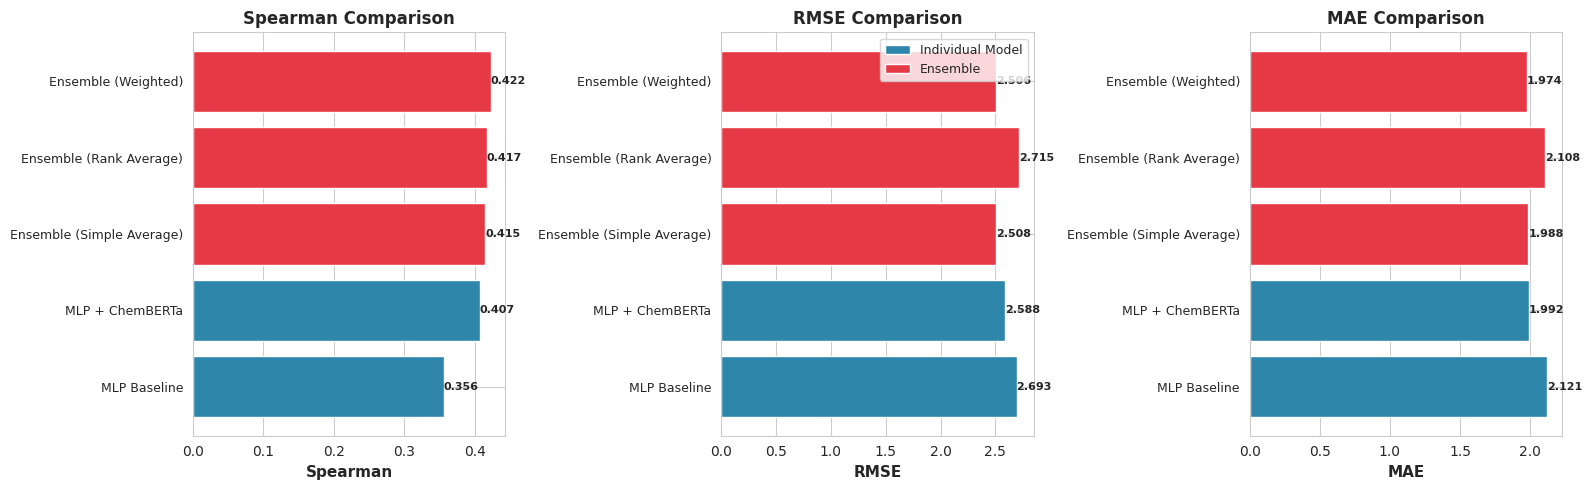

In [31]:
# Compile all results
all_results = individual_results + [
    metrics_simple,
    metrics_weighted,
    {'Model': 'Ensemble (Rank Average)', 'Spearman': spearman_rank, 'RMSE': rmse_rank, 'MAE': mae_rank}
]

df_all = pd.DataFrame(all_results)

# Mark ensemble models
df_all['Type'] = df_all['Model'].apply(lambda x: 'Ensemble' if 'Ensemble' in x else 'Individual')

# Sort by Spearman
df_all = df_all.sort_values('Spearman', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ['Spearman', 'RMSE', 'MAE']
colors = ['#2E86AB' if t == 'Individual' else '#E63946' for t in df_all['Type']]

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    bars = ax.barh(range(len(df_all)), df_all[metric], color=colors)
    ax.set_yticks(range(len(df_all)))
    ax.set_yticklabels(df_all['Model'], fontsize=9)
    ax.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.invert_yaxis()

    # Add values on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
               f'{width:.3f}',
               ha='left', va='center', fontsize=8, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label='Individual Model'),
    Patch(facecolor='#E63946', label='Ensemble')
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Best Ensemble Selection

In [32]:
# Determine best ensemble strategy
ensemble_results = df_all[df_all['Type'] == 'Ensemble'].sort_values('Spearman', ascending=False)

print("\n" + "="*70)
print("ENSEMBLE STRATEGY COMPARISON")
print("="*70)
print(ensemble_results[['Model', 'Spearman', 'RMSE', 'MAE']].to_string(index=False))
print("="*70)

best_ensemble = ensemble_results.iloc[0]
print(f"\n🏆 Best Ensemble: {best_ensemble['Model']}")
print(f"   Spearman: {best_ensemble['Spearman']:.4f}")
print(f"   RMSE:     {best_ensemble['RMSE']:.4f}")
print(f"   MAE:      {best_ensemble['MAE']:.4f}")

best_individual = df_all[df_all['Type'] == 'Individual'].iloc[0]
improvement = (best_ensemble['Spearman'] - best_individual['Spearman']) * 100
print(f"\n📈 Improvement over best individual ({best_individual['Model']}): {improvement:.2f}%")


ENSEMBLE STRATEGY COMPARISON
                    Model  Spearman     RMSE      MAE
      Ensemble (Weighted)  0.422477 2.505739 1.974028
  Ensemble (Rank Average)  0.417292 2.714880 2.107919
Ensemble (Simple Average)  0.414585 2.508090 1.987551

🏆 Best Ensemble: Ensemble (Weighted)
   Spearman: 0.4225
   RMSE:     2.5057
   MAE:      1.9740

📈 Improvement over best individual (MLP + ChemBERTa): 1.56%


## 10. Prediction Scatter Plots

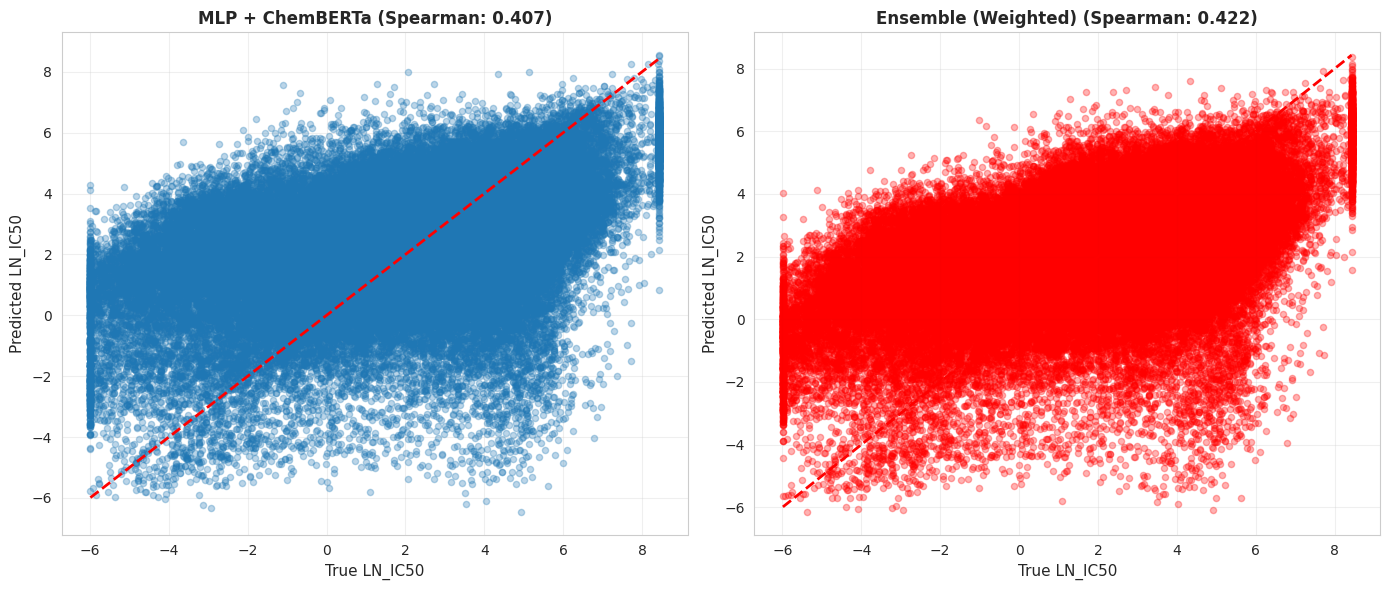

In [33]:
# Compare best individual vs best ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Best individual
best_ind_preds = predictions[best_individual['Model']]
mask_ind = ~np.isnan(best_ind_preds)

axes[0].scatter(y_test[mask_ind], best_ind_preds[mask_ind], alpha=0.3, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('True LN_IC50', fontsize=11)
axes[0].set_ylabel('Predicted LN_IC50', fontsize=11)
axes[0].set_title(f'{best_individual["Model"]} (Spearman: {best_individual["Spearman"]:.3f})',
                 fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Best ensemble
if best_ensemble['Model'] == 'Ensemble (Simple Average)':
    ensemble_preds = ensemble_simple
elif best_ensemble['Model'] == 'Ensemble (Weighted)':
    ensemble_preds = ensemble_weighted
else:
    ensemble_preds = ensemble_rank_vals

mask_ens = ~np.isnan(ensemble_preds)

axes[1].scatter(y_test[mask_ens], ensemble_preds[mask_ens], alpha=0.3, s=20, color='red')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('True LN_IC50', fontsize=11)
axes[1].set_ylabel('Predicted LN_IC50', fontsize=11)
axes[1].set_title(f'{best_ensemble["Model"]} (Spearman: {best_ensemble["Spearman"]:.3f})',
                 fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Save Best Ensemble Predictions

In [34]:
# Save best ensemble predictions and weights
output_dir = RESULTS_DIR / 'ensemble'
output_dir.mkdir(exist_ok=True)

# Save predictions
if best_ensemble['Model'] == 'Ensemble (Simple Average)':
    np.save(output_dir / 'test_preds.npy', ensemble_simple)
    ensemble_type = 'simple'
elif best_ensemble['Model'] == 'Ensemble (Weighted)':
    np.save(output_dir / 'test_preds.npy', ensemble_weighted)
    ensemble_type = 'weighted'
    # Save weights
    weights_df = pd.DataFrame({
        'Model': list(predictions.keys()),
        'Weight': optimal_weights
    })
    weights_df.to_csv(output_dir / 'optimal_weights.csv', index=False)
else:
    np.save(output_dir / 'test_preds.npy', ensemble_rank_vals)
    ensemble_type = 'rank'

# Save metrics
metrics_df = pd.DataFrame([best_ensemble])
metrics_df.to_csv(output_dir / 'metrics_test.csv', index=False)

# Save configuration
config = {
    'ensemble_type': ensemble_type,
    'models_used': list(predictions.keys()),
    'n_models': len(predictions),
    'test_spearman': float(best_ensemble['Spearman']),
    'test_rmse': float(best_ensemble['RMSE']),
    'test_mae': float(best_ensemble['MAE'])
}

import json
with open(output_dir / 'ensemble_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("\n✓ Best ensemble saved to:", output_dir)
print(f"  - test_preds.npy")
print(f"  - metrics_test.csv")
print(f"  - ensemble_config.json")
if ensemble_type == 'weighted':
    print(f"  - optimal_weights.csv")


✓ Best ensemble saved to: results/ensemble
  - test_preds.npy
  - metrics_test.csv
  - ensemble_config.json
  - optimal_weights.csv


## 12. Summary and Insights

In [35]:
print("="*90)
print("ENSEMBLE MODEL SUMMARY")
print("="*90)

print(f"\n📊 MODELS COMBINED: {len(predictions)}")
for i, model in enumerate(predictions.keys(), 1):
    print(f"   {i}. {model}")

print(f"\n🏆 BEST STRATEGY: {best_ensemble['Model']}")
print(f"   • Spearman: {best_ensemble['Spearman']:.4f}")
print(f"   • RMSE:     {best_ensemble['RMSE']:.4f}")
print(f"   • MAE:      {best_ensemble['MAE']:.4f}")

print(f"\n📈 PERFORMANCE GAIN:")
print(f"   • Best individual: {best_individual['Model']} (Spearman: {best_individual['Spearman']:.4f})")
print(f"   • Ensemble improvement: +{improvement:.2f}%")

if ensemble_type == 'weighted':
    print(f"\n⚖️ MODEL WEIGHTS (Optimized):")
    weights_sorted = sorted(zip(predictions.keys(), optimal_weights), key=lambda x: x[1], reverse=True)
    for model, weight in weights_sorted:
        print(f"   • {model:30s}: {weight:.4f} ({weight*100:.1f}%)")

print("\n💡 KEY INSIGHTS:")
if improvement > 0:
    print("   ✓ Ensemble outperforms individual models")
    print("   ✓ Model diversity contributes to better predictions")
else:
    print("   • Ensemble matches best individual (models may be correlated)")
    print("   • Consider adding more diverse model architectures")

print("\n🎯 RECOMMENDATIONS:")
print("   1. Use ensemble for production predictions")
print("   2. Monitor individual model performance over time")
print("   3. Retrain weights if new models are added")
print("   4. Consider confidence intervals using model variance")

print("\n" + "="*90)

ENSEMBLE MODEL SUMMARY

📊 MODELS COMBINED: 2
   1. MLP Baseline
   2. MLP + ChemBERTa

🏆 BEST STRATEGY: Ensemble (Weighted)
   • Spearman: 0.4225
   • RMSE:     2.5057
   • MAE:      1.9740

📈 PERFORMANCE GAIN:
   • Best individual: MLP + ChemBERTa (Spearman: 0.4069)
   • Ensemble improvement: +1.56%

⚖️ MODEL WEIGHTS (Optimized):
   • MLP + ChemBERTa               : 0.6803 (68.0%)
   • MLP Baseline                  : 0.3197 (32.0%)

💡 KEY INSIGHTS:
   ✓ Ensemble outperforms individual models
   ✓ Model diversity contributes to better predictions

🎯 RECOMMENDATIONS:
   1. Use ensemble for production predictions
   2. Monitor individual model performance over time
   3. Retrain weights if new models are added
   4. Consider confidence intervals using model variance



## 13. Model Weight Distribution Heatmap

Visualize optimized weights and prediction distance matrix.

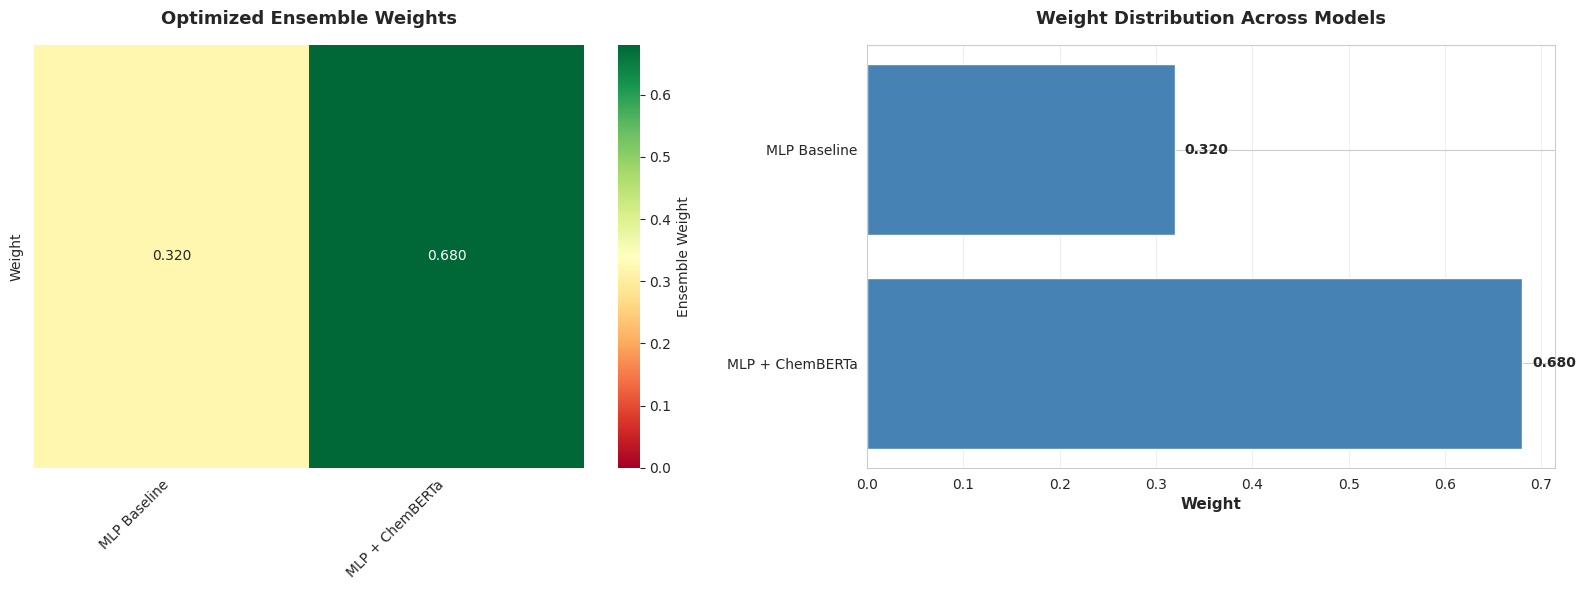


💡 Interpretation:
   • Highest weight: MLP + ChemBERTa (0.680)
   • Lowest weight: MLP Baseline (0.320)
   • Weight spread: 0.180 (std dev)


In [36]:
# Visualize ensemble weights (if weighted ensemble was best)
if 'optimal_weights' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Weight heatmap
    weights_reshaped = optimal_weights.reshape(-1, 1)
    models_list = list(predictions.keys())

    sns.heatmap(
        weights_reshaped.T,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        vmin=0,
        vmax=optimal_weights.max(),
        xticklabels=models_list,
        yticklabels=['Weight'],
        cbar_kws={'label': 'Ensemble Weight'},
        ax=axes[0]
    )
    axes[0].set_title('Optimized Ensemble Weights', fontsize=13, fontweight='bold', pad=15)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

    # Bar chart version
    axes[1].barh(range(len(models_list)), optimal_weights, color='steelblue')
    axes[1].set_yticks(range(len(models_list)))
    axes[1].set_yticklabels(models_list)
    axes[1].set_xlabel('Weight', fontsize=11, fontweight='bold')
    axes[1].set_title('Weight Distribution Across Models', fontsize=13, fontweight='bold', pad=15)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)

    # Add value labels
    for i, weight in enumerate(optimal_weights):
        axes[1].text(weight + 0.01, i, f'{weight:.3f}', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n💡 Interpretation:")
    print(f"   • Highest weight: {models_list[optimal_weights.argmax()]} ({optimal_weights.max():.3f})")
    print(f"   • Lowest weight: {models_list[optimal_weights.argmin()]} ({optimal_weights.min():.3f})")
    print(f"   • Weight spread: {optimal_weights.std():.3f} (std dev)")
else:
    print("⚠ Weighted ensemble not computed - optimal_weights not available")

## 14. Prediction Distance Matrix

Hierarchical clustering of models based on prediction similarity.

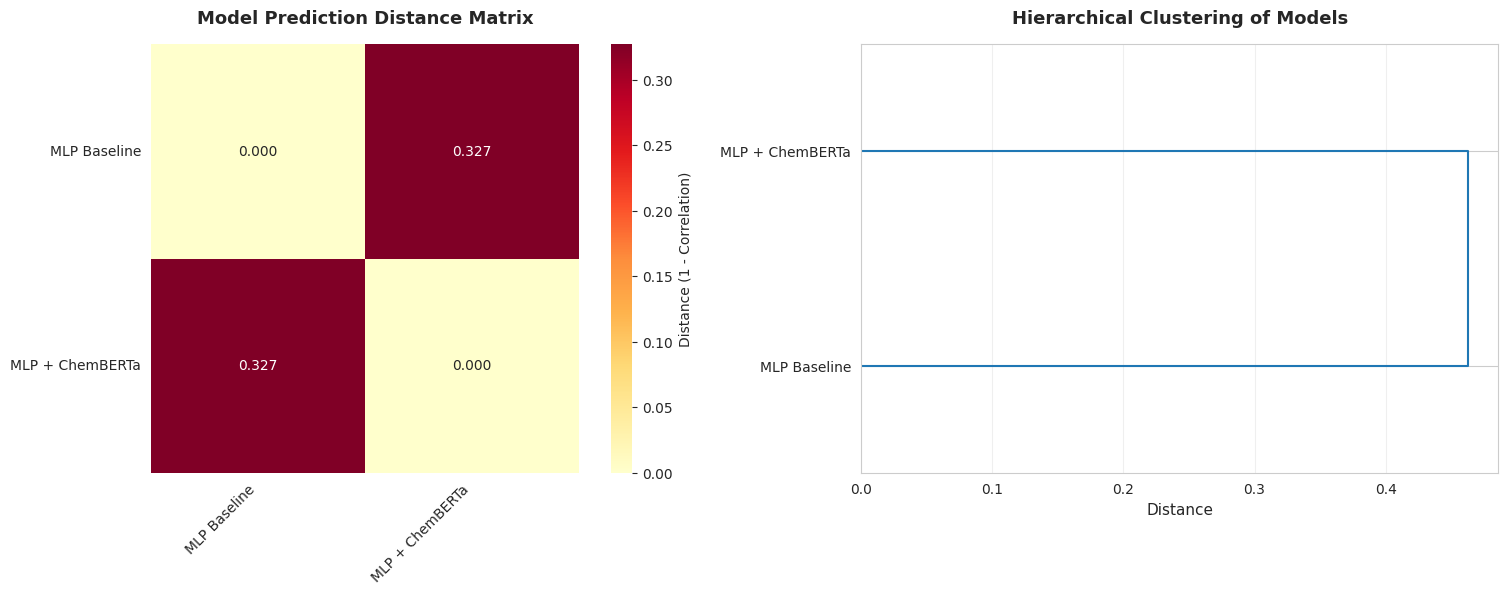


💡 Interpretation:
   • Left: Distance matrix (low values = similar predictions)
   • Right: Dendrogram showing model clusters
   • Models closer together make similar predictions
   • Most similar pair: MLP Baseline ↔ MLP + ChemBERTa
     Distance: 0.327


In [37]:
# Compute pairwise distances between model predictions
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage

# Remove NaN values for distance computation
pred_matrix_clean = pred_matrix.copy()
mask = ~np.any(np.isnan(pred_matrix_clean), axis=1)
pred_matrix_clean = pred_matrix_clean[mask]

# Compute pairwise distances (1 - correlation)
model_names_list = list(predictions.keys())
n_models = len(model_names_list)
distance_matrix = np.zeros((n_models, n_models))

for i in range(n_models):
    for j in range(n_models):
        if i == j:
            distance_matrix[i, j] = 0
        else:
            corr = np.corrcoef(pred_matrix_clean[:, i], pred_matrix_clean[:, j])[0, 1]
            distance_matrix[i, j] = 1 - corr  # Convert correlation to distance

# Create clustered heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distance matrix heatmap
sns.heatmap(
    distance_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    xticklabels=model_names_list,
    yticklabels=model_names_list,
    cbar_kws={'label': 'Distance (1 - Correlation)'},
    ax=axes[0],
    square=True
)
axes[0].set_title('Model Prediction Distance Matrix', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Dendrogram
linkage_matrix = linkage(distance_matrix, method='ward')
dendrogram(
    linkage_matrix,
    labels=model_names_list,
    ax=axes[1],
    leaf_font_size=10,
    orientation='right'
)
axes[1].set_title('Hierarchical Clustering of Models', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Distance', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   • Left: Distance matrix (low values = similar predictions)")
print("   • Right: Dendrogram showing model clusters")
print("   • Models closer together make similar predictions")
most_similar_idx = np.unravel_index(
    np.ma.masked_equal(distance_matrix, 0).argmin(),
    distance_matrix.shape
)
print(f"   • Most similar pair: {model_names_list[most_similar_idx[0]]} ↔ {model_names_list[most_similar_idx[1]]}")
print(f"     Distance: {distance_matrix[most_similar_idx]:.3f}")